# MotionSense: first look at the data

**How to use:** change the settings in the **Inputs** cell, then *Run All*. Every plot below follows those settings.

### Imports & plot style

In [73]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf

COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]  # fixed categorical order

plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e4e3df", "grid.linewidth": 0.6,
    "axes.edgecolor": "#8a8984", "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
    "lines.linewidth": 1.2,
})

### Inputs

In [ ]:
DATA_DIR = Path("A_DeviceMotion_data_split/train")
FS = 50                          # DeviceMotion sampling rate (Hz)

SUBJECT = 1                      # subject for the single-subject plots (1-24)
ACTIVITY, TRIAL = "wlk", 7       # recording for the ACF/PACF and single-recording plots
WINDOW_S = 10                    # seconds shown in time-series plots
COMPARE_SUBJECTS = [1, 2, 3, 4]  # subjects in the between-subject plot (max 4)
COMPARE_WINDOW_S = 5             # seconds shown in the between-subject plot
ACF_LAGS_S = 3                   # ACF/PACF horizon (seconds)
M = None                         # seasonal period in samples. None = derive from the ACF peaks

### Load data & initial analysis

In [75]:
ACTIVITY_NAMES = {"dws": "Downstairs", "ups": "Upstairs", "wlk": "Walking",
                  "jog": "Jogging", "sit": "Sitting", "std": "Standing"}
ACTIVITY_ORDER = list(ACTIVITY_NAMES)

# Folder "wlk_7" -> activity "wlk", trial 7. file "sub_3.csv" -> subject 3
frames = []
for f in sorted(DATA_DIR.glob("*/sub_*.csv")):
    activity, trial = f.parent.name.split("_")
    rec = pd.read_csv(f, index_col=0)  # first column is the sample counter
    rec.index.name = "sample"
    rec = rec.reset_index()
    rec.insert(0, "activity", activity)
    rec.insert(1, "trial", int(trial))
    rec.insert(2, "subject", int(f.stem.split("_")[1]))
    frames.append(rec)

df = pd.concat(frames, ignore_index=True)
df.insert(4, "time_s", df["sample"] / FS)
KEYS = ["activity", "trial", "subject"]  # one recording
# Yaw wraps at +/- pi. Unwrap it per recording so the jumps aren't mistaken for motion
df["attitude.yaw"] = df.groupby(KEYS)["attitude.yaw"].transform(np.unwrap)

ATT = ["attitude.roll", "attitude.pitch", "attitude.yaw"]
GRAV = ["gravity.x", "gravity.y", "gravity.z"]
ACC = ["userAcceleration.x", "userAcceleration.y", "userAcceleration.z"]
GYRO = ["rotationRate.x", "rotationRate.y", "rotationRate.z"]
# Magnitudes don't depend on how the phone sits in the pocket
df["acc_mag"] = np.sqrt((df[ACC] ** 2).sum(axis=1))
df["gyro_mag"] = np.sqrt((df[GYRO] ** 2).sum(axis=1))

# Every signal grouped by sensor
GROUPS = {
    "attitude (rad)": ATT,
    "gravity (g)": GRAV,
    "rotationRate (rad/s)": GYRO,
    "userAcceleration (g)": ACC,
    "|userAcceleration| (g)": ["acc_mag"],
    "|rotationRate| (rad/s)": ["gyro_mag"],
}
SIGNALS = [c for cols in GROUPS.values() for c in cols]  # 12 raw channels + 2 magnitudes
UNITS = {c: name[name.index("(") + 1:-1] for name, cols in GROUPS.items() for c in cols}


def get_recording(activity, trial, subject, window_s=None, data=None):
    """One recording from df (or `data`), optionally only its first window_s seconds."""
    data = df if data is None else data
    rec = data[(data.activity == activity) & (data.trial == trial) & (data.subject == subject)]
    return rec if window_s is None else rec[rec.time_s < window_s]


# Initial analysis
lengths = df.groupby(KEYS).size() / FS
missing = df.isna().sum()
print(f"Rows: {len(df):,}  |  recordings: {len(lengths)}  |  total duration: {len(df) / FS / 3600:.2f} h")
print(f"Missing values: {missing.sum()}" + ("" if missing.sum() == 0 else f"\n{missing[missing > 0]}"))
per_subject = lengths.groupby("subject").size()
print(f"Subjects: {df.subject.nunique()}  |  recordings per subject: {per_subject.min()}-{per_subject.max()}")

TRIALS = {a: sorted(int(t) for t in df.loc[df.activity == a, "trial"].unique()) for a in ACTIVITY_ORDER}
print("\nTrials per activity:")
for a, t in TRIALS.items():
    print(f"  {a} ({ACTIVITY_NAMES[a]}): {t}")

print("\nRecording length by activity (s):")
display(lengths.groupby("activity").describe()[["count", "min", "50%", "max"]]
        .reindex(ACTIVITY_ORDER).rename(columns={"50%": "median"}).round(1))

# Validate inputs
subjects = sorted(int(s) for s in df.subject.unique())
if SUBJECT not in subjects:
    raise ValueError(f"SUBJECT = {SUBJECT} not found. Choose from {subjects}")
if ACTIVITY not in TRIALS or TRIAL not in TRIALS[ACTIVITY]:
    raise ValueError(f"No recording {ACTIVITY}_{TRIAL}. Available trials: {TRIALS}")
if bad := sorted(set(COMPARE_SUBJECTS) - set(subjects)):
    raise ValueError(f"COMPARE_SUBJECTS contains unknown subject(s) {bad}. Choose from {subjects}")
if len(COMPARE_SUBJECTS) > len(COLORS):
    raise ValueError(f"COMPARE_SUBJECTS can hold at most {len(COLORS)} subjects")

sel = get_recording(ACTIVITY, TRIAL, SUBJECT)
print(f"\nSelected: subject {SUBJECT}, recording {ACTIVITY}_{TRIAL} ({len(sel)} samples, {len(sel) / FS:.1f} s)")

ValueError: No objects to concatenate

### Seasonal differencing for every recording

Each recording gets its own season length `m`: for each signal, the highest ACF peak after the initial decay, then the median across signals. A peak only counts if it is strong (ACF ≥ `MIN_PEAK_ACF`) and clear (rises ≥ `MIN_PROMINENCE` above the dip before it), and a recording only gets an `m` if at least `MIN_SIGNALS` signals agree. Recordings with no repeating pattern (standing, nearly all sitting, a few short stair runs) get no `m` and aren't differenced. Set `M` in Inputs to force one `m` for everything.

`df_diff` holds `y_t − y_{t−m}` for every signal, in the same layout as `df`. All the cells below plot `df` (raw) and `df_diff` (delta_m) side by side.

In [ ]:
N_LAGS = ACF_LAGS_S * FS
MIN_PEAK_ACF = 0.3     # a season's ACF peak must reach this...
MIN_PROMINENCE = 0.3   # ...and rise this far above the dip before it
MIN_SIGNALS = 3        # how many of the 14 signals must show a season


def dominant_lag(r):
    """Highest ACF peak after the initial decay (first lag where the ACF turns back up). NaN if too weak."""
    rising = np.flatnonzero(np.diff(r) > 0)
    if not rising.size:
        return np.nan
    peak = rising[0] + np.nanargmax(r[rising[0]:])
    strong = r[peak] >= MIN_PEAK_ACF and r[peak] - np.nanmin(r[:peak + 1]) >= MIN_PROMINENCE
    return int(peak) if strong else np.nan


def season_length(rec):
    """Median dominant lag across signals. NaN unless at least MIN_SIGNALS signals repeat."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")  # constant signals -> division by zero in acf
        lags = np.array([dominant_lag(acf(rec[c], nlags=N_LAGS)) for c in SIGNALS], dtype=float)
    return np.nan if np.sum(~np.isnan(lags)) < MIN_SIGNALS else int(np.nanmedian(lags))


m_of, diff_frames = {}, []
for key, rec in df.groupby(KEYS):
    m_rec = M if M is not None else season_length(rec)
    m_of[key] = m_rec
    if not np.isnan(m_rec):
        d = rec.copy()
        d[SIGNALS] = rec[SIGNALS].diff(m_rec)  # y_t - y_{t-m}
        diff_frames.append(d.iloc[m_rec:])
df_diff = pd.concat(diff_frames)
m_table = pd.Series(m_of, name="m").rename_axis(KEYS)


def m_label(activity, trial, subject):
    m = m_of[(activity, trial, subject)]
    return "no period" if np.isnan(m) else f"m = {m:.0f}"


summary = m_table.groupby("activity").agg(recordings="size", with_period="count", m_min="min", m_median="median", m_max="max")
display(summary.reindex(ACTIVITY_ORDER))
print(f"Selected recording {ACTIVITY}_{TRIAL}, subject {SUBJECT}: {m_label(ACTIVITY, TRIAL, SUBJECT)}")

,recordings,with_period,m_min,m_median,m_max
activity,,,,,
dws,72,59,24.0,44.0,59.0
ups,72,70,31.0,57.0,78.0
wlk,72,72,44.0,53.0,58.0
jog,48,48,32.0,36.0,40.0
sit,48,3,15.0,16.0,50.0
std,48,0,NaN,NaN,NaN


Selected recording wlk_7, subject 1: m = 53


### ACF / PACF before vs after (selected recording)

One figure per sensor group: raw ACF | raw PACF | delta_m ACF | delta_m PACF. Dashed line = lag `m`. Shaded band = 95% confidence interval. If `m` is right, the waves in the raw ACF disappear after differencing.

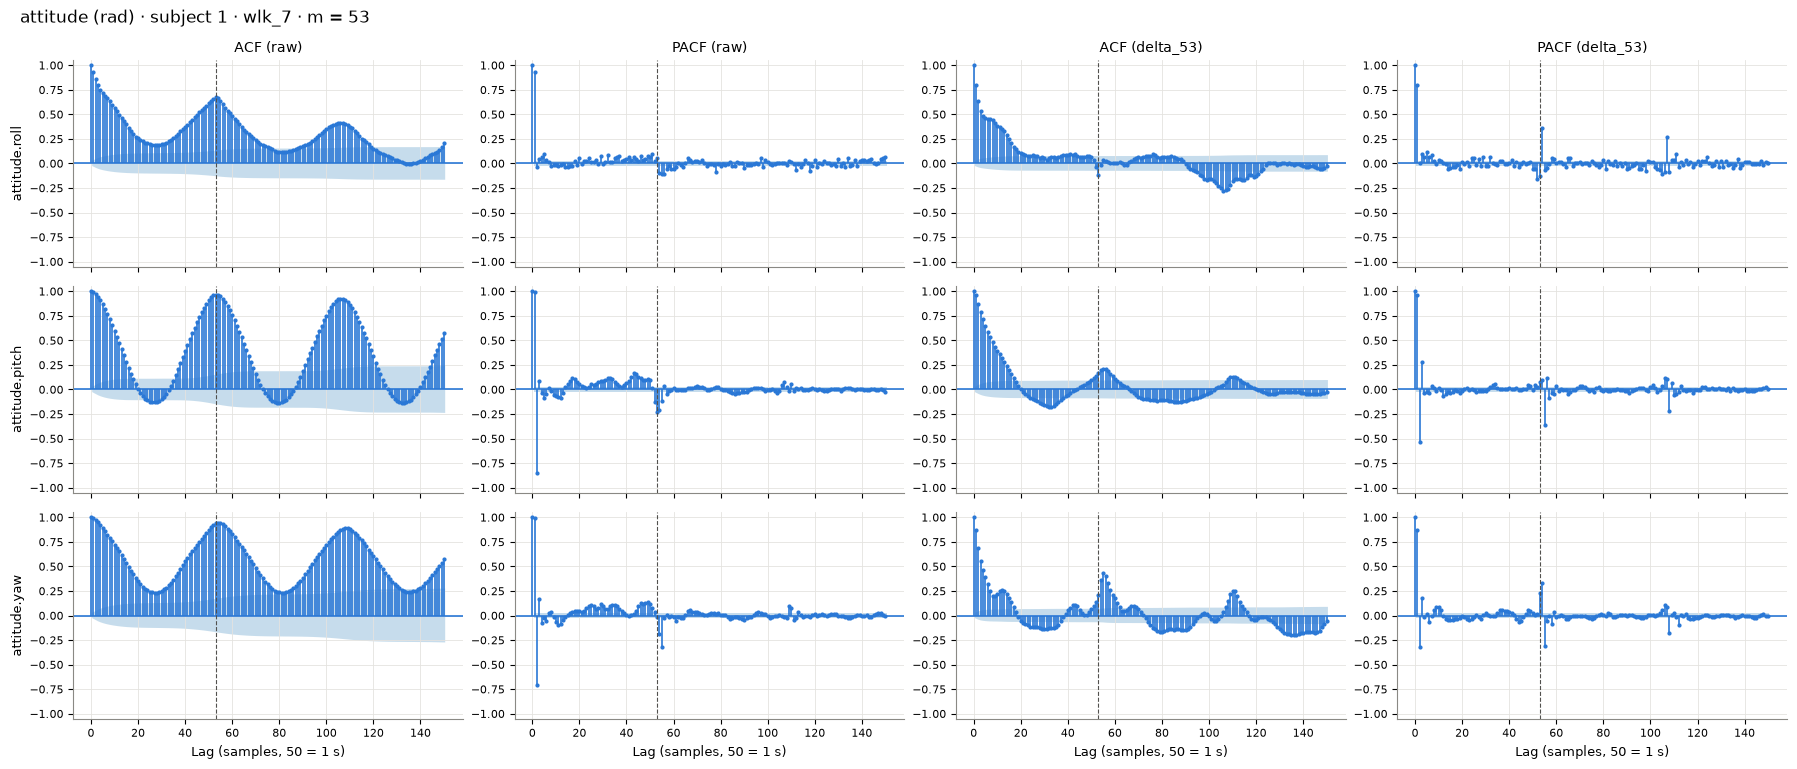

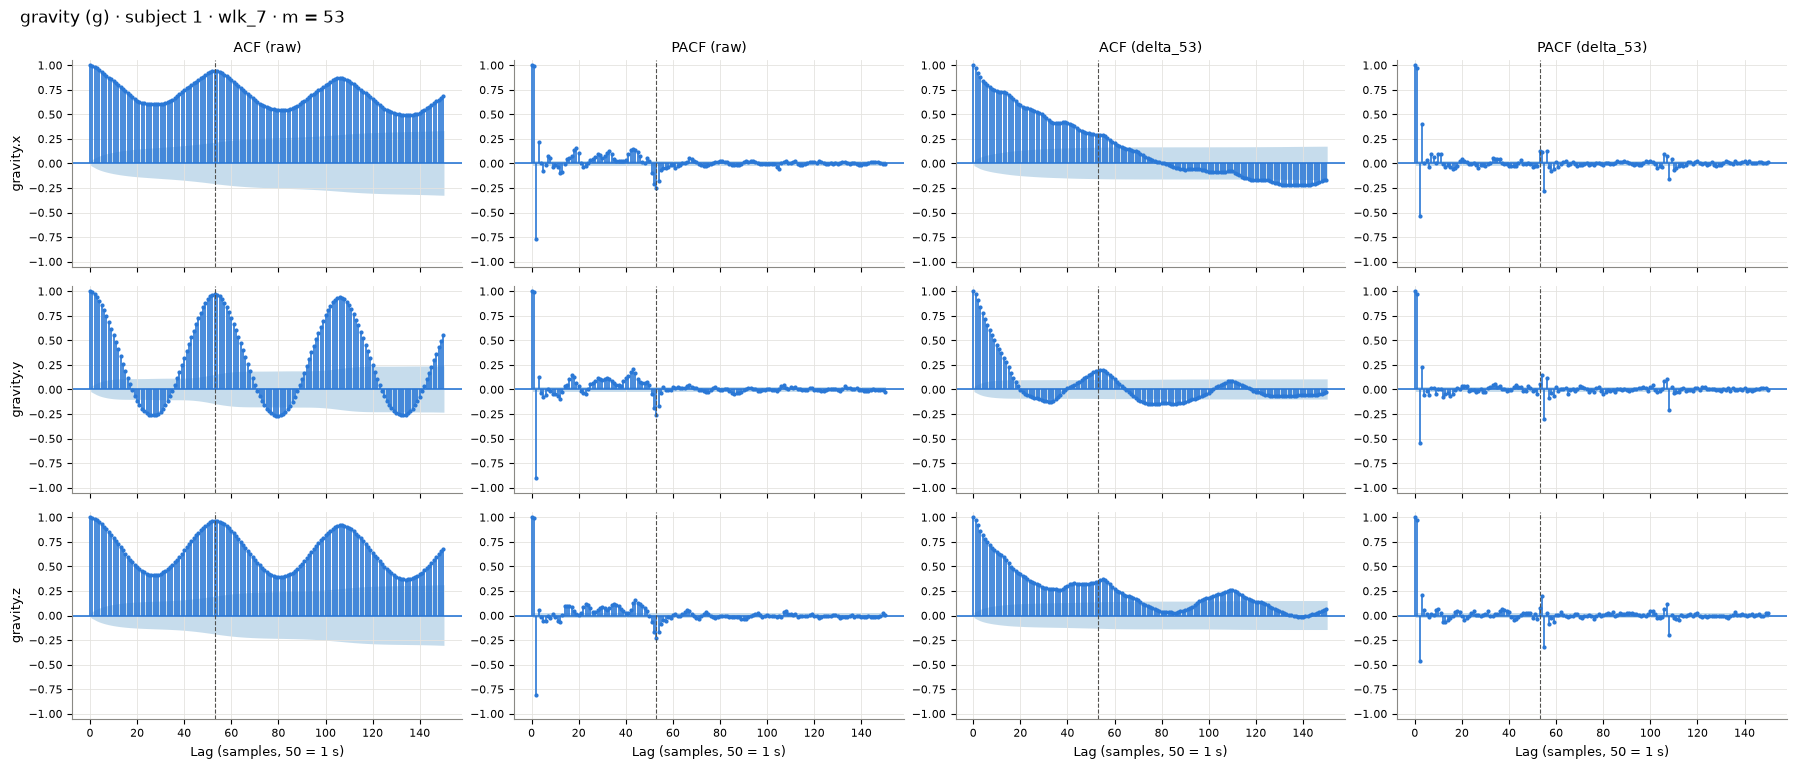

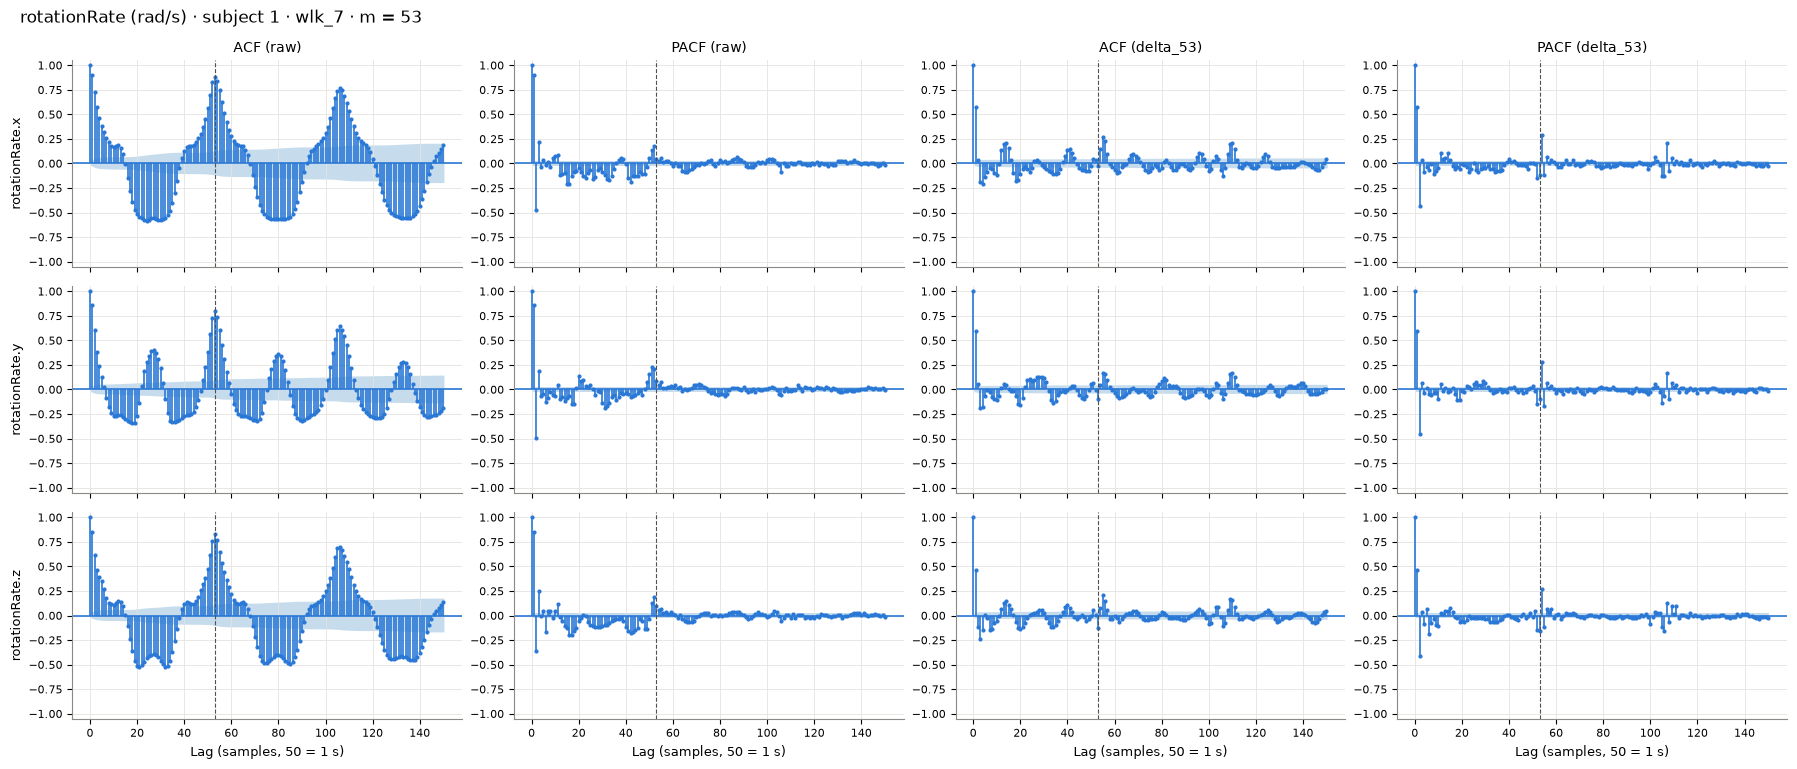

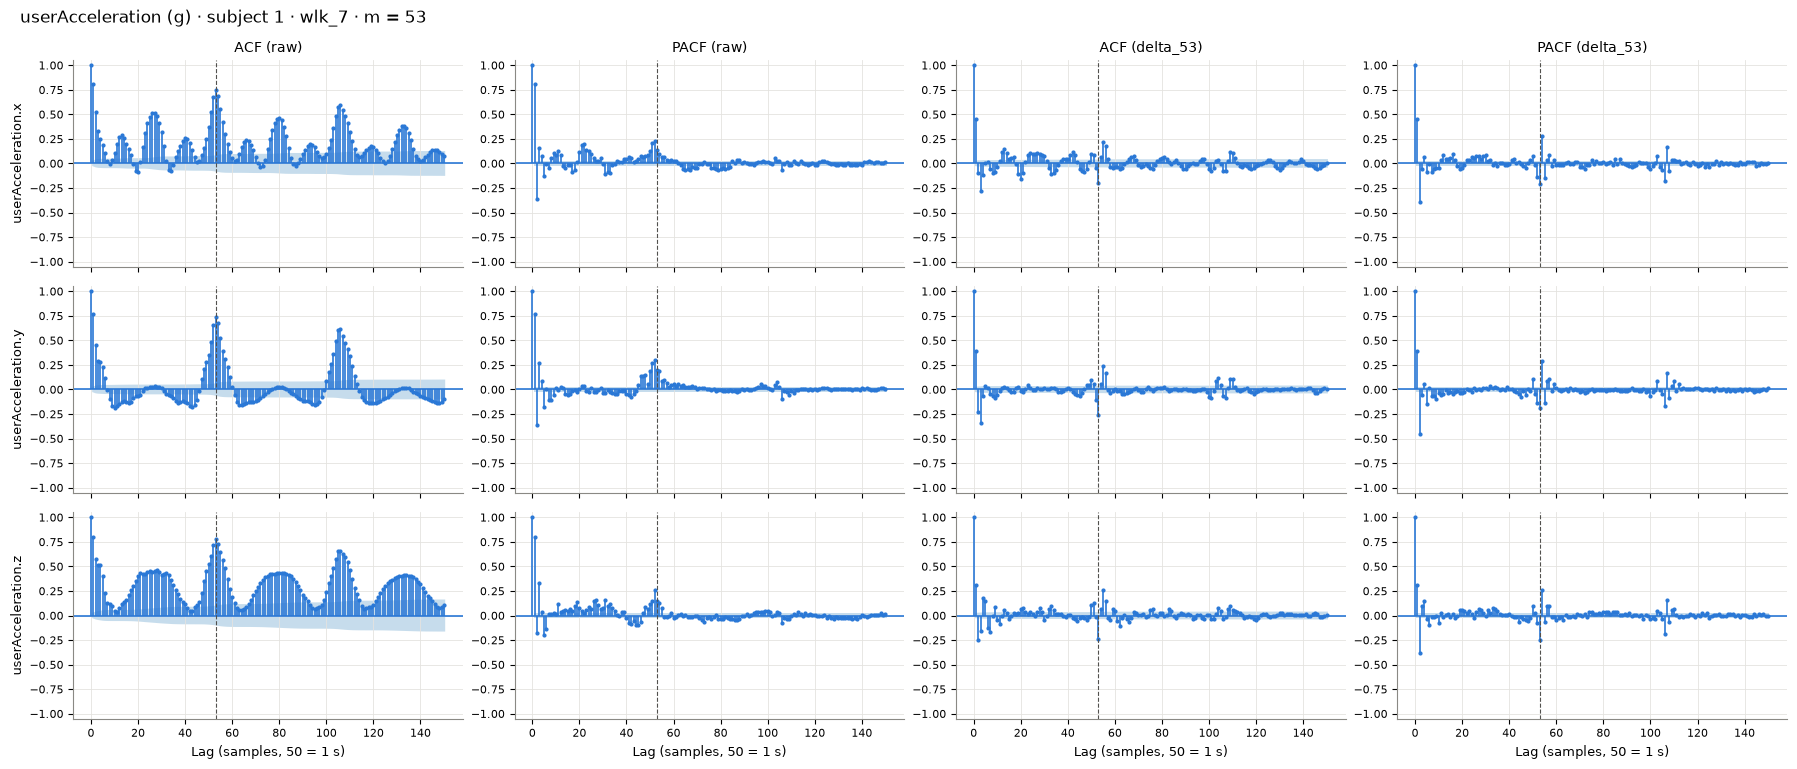

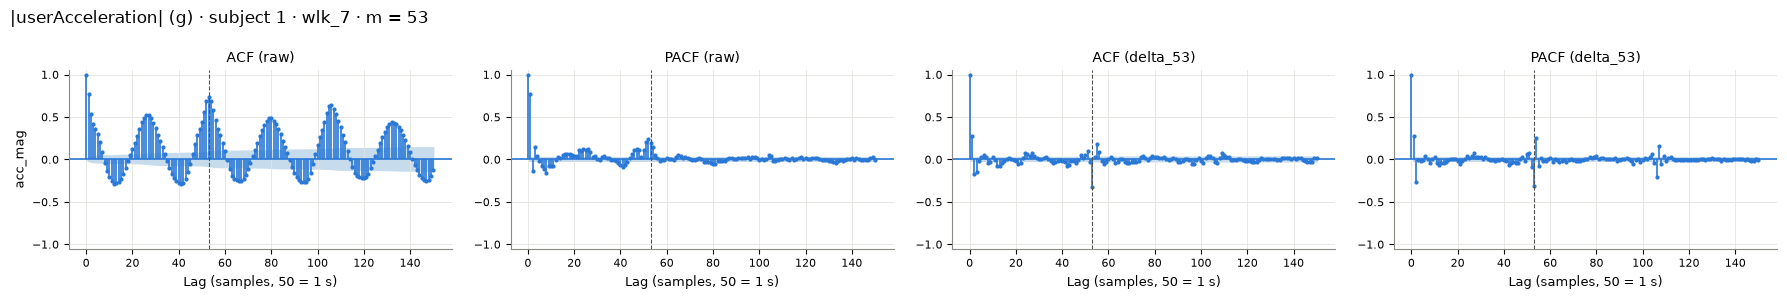

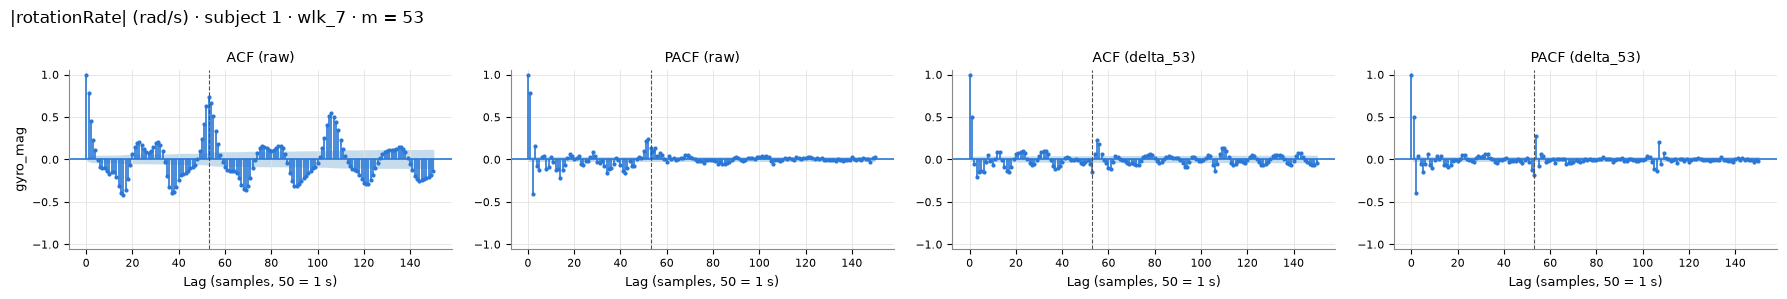

,peak_lag,acf@53 before,acf@53 after
attitude.roll,53,0.67,-0.12
attitude.pitch,53,0.97,0.16
attitude.yaw,54,0.94,0.21
gravity.x,53,0.94,0.29
gravity.y,53,0.97,0.19
gravity.z,53,0.97,0.34
rotationRate.x,53,0.88,-0.02
rotationRate.y,53,0.80,-0.10
rotationRate.z,53,0.83,-0.13
userAcceleration.x,53,0.74,-0.20


In [ ]:
m = m_of[(ACTIVITY, TRIAL, SUBJECT)]
if np.isnan(m):
    print(f"Skipped: {ACTIVITY}_{TRIAL} (subject {SUBJECT}) has no clear seasonal period. "
          "Pick a walking/jogging/stairs recording or set M in Inputs.")
else:
    m = int(m)
    raw = get_recording(ACTIVITY, TRIAL, SUBJECT)
    dif = get_recording(ACTIVITY, TRIAL, SUBJECT, data=df_diff)

    for name, cols in GROUPS.items():
        fig, axes = plt.subplots(len(cols), 4, figsize=(18, 2.4 * len(cols) + 0.6), sharex=True, squeeze=False)
        for row, sig in zip(axes, cols):
            panels = [(plot_acf, raw), (plot_pacf, raw), (plot_acf, dif), (plot_pacf, dif)]
            for ax, (plot_fn, data) in zip(row, panels):
                extra = {"method": "ywm"} if plot_fn is plot_pacf else {}
                plot_fn(data[sig].to_numpy(), lags=N_LAGS, ax=ax, title="", markersize=2, color=COLORS[0],
                        vlines_kwargs={"colors": COLORS[0]}, **extra)
                ax.axvline(m, color="#52514e", linestyle="--", linewidth=0.8)
                ax.set_ylim(-1.05, 1.05)
            row[0].set_ylabel(sig)
        for ax, title in zip(axes[0], ["ACF (raw)", "PACF (raw)", f"ACF (delta_{m})", f"PACF (delta_{m})"]):
            ax.set_title(title)
        for ax in axes[-1]:
            ax.set_xlabel("Lag (samples, 50 = 1 s)")
        fig.suptitle(f"{name} · subject {SUBJECT} · {ACTIVITY}_{TRIAL} · m = {m}", x=0.01, ha="left")
        plt.tight_layout()
        plt.show()

    nlags_m = max(N_LAGS, m)
    display(pd.DataFrame({
        "peak_lag": {c: dominant_lag(acf(raw[c], nlags=N_LAGS)) for c in SIGNALS},
        f"acf@{m} before": {c: acf(raw[c], nlags=nlags_m)[m] for c in SIGNALS},
        f"acf@{m} after": {c: acf(dif[c], nlags=nlags_m)[m] for c in SIGNALS},
    }).round(2))

### Activity signatures before vs after (selected subject)

One figure per sensor group. Top row = raw, bottom row = delta_m. Columns = activities, each differenced with its own `m`. y-axes are shared within each row.

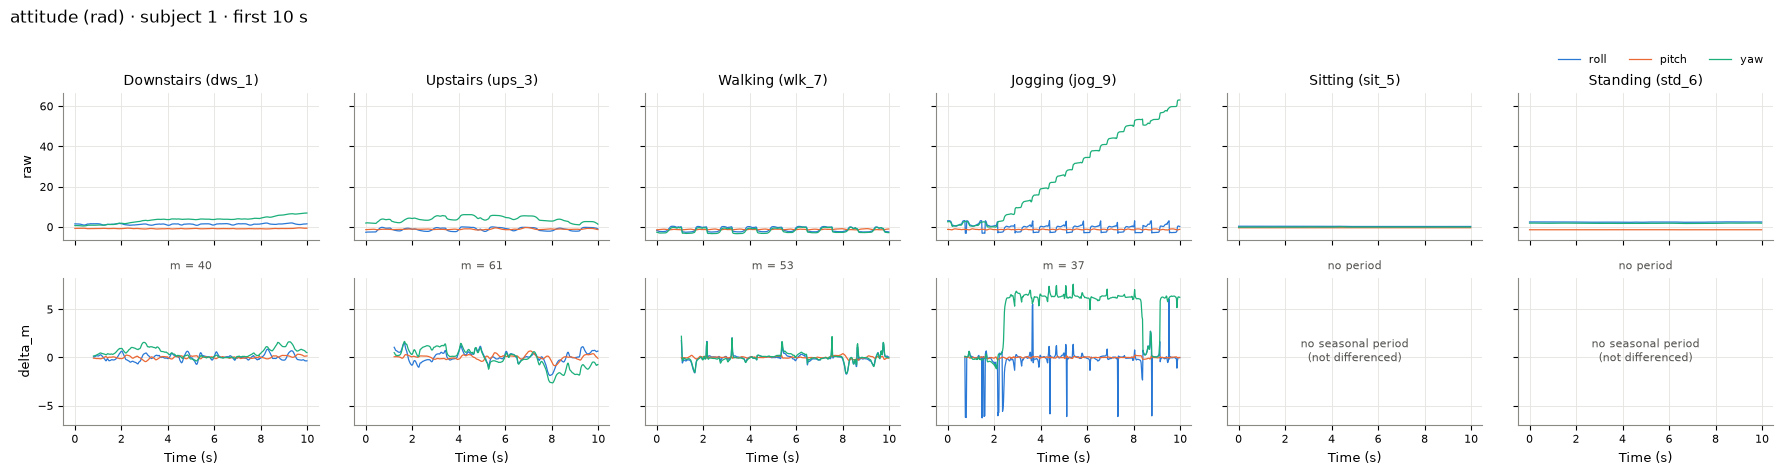

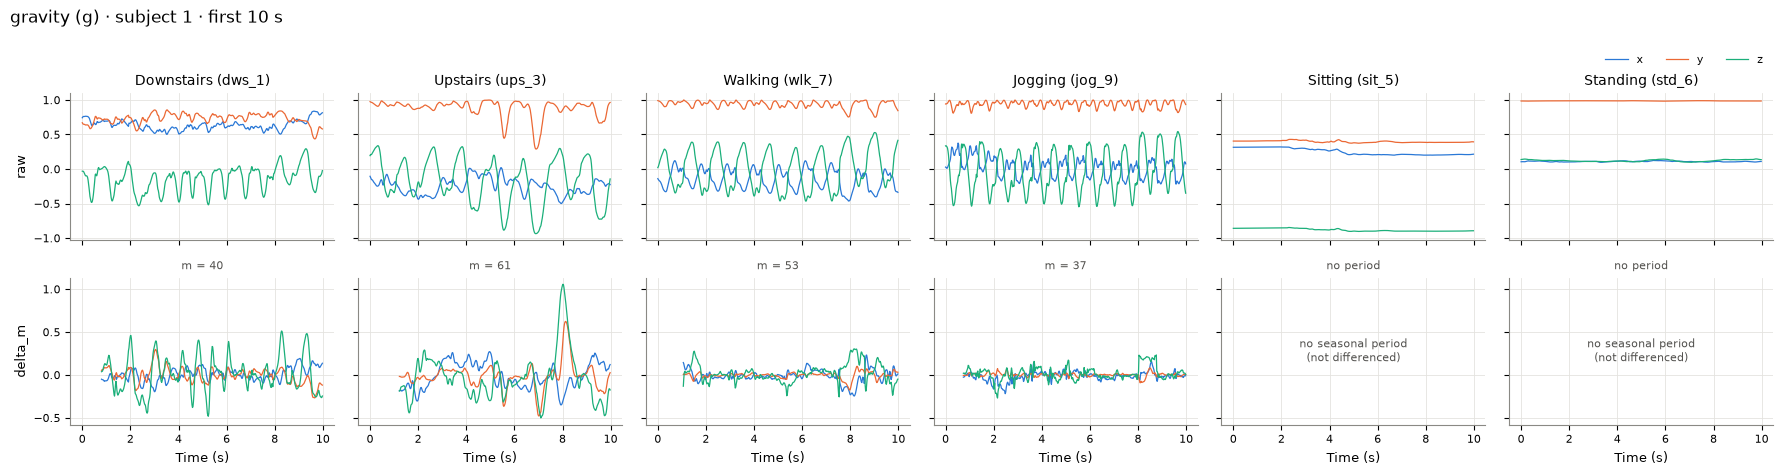

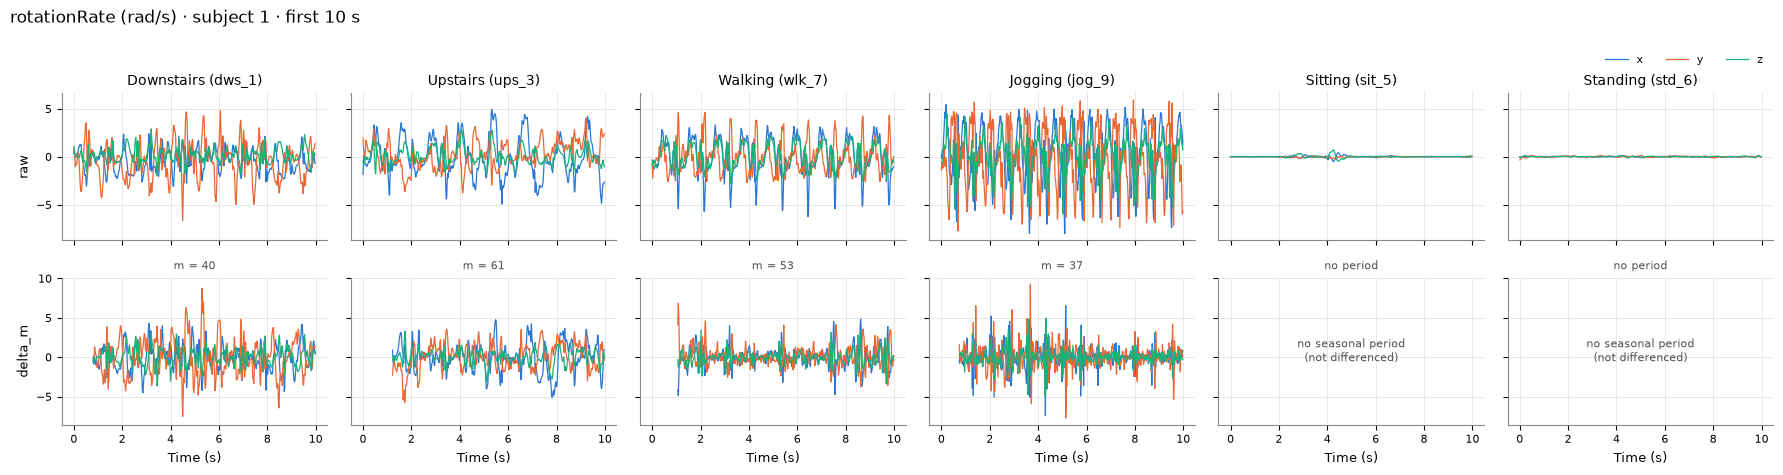

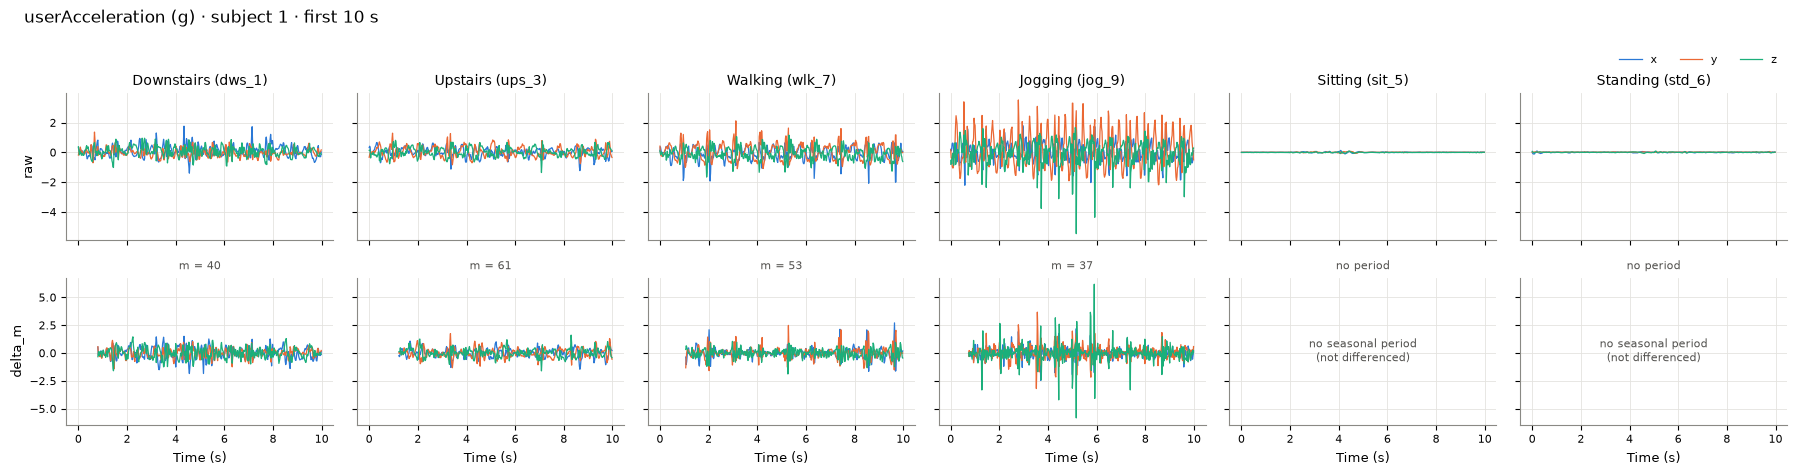

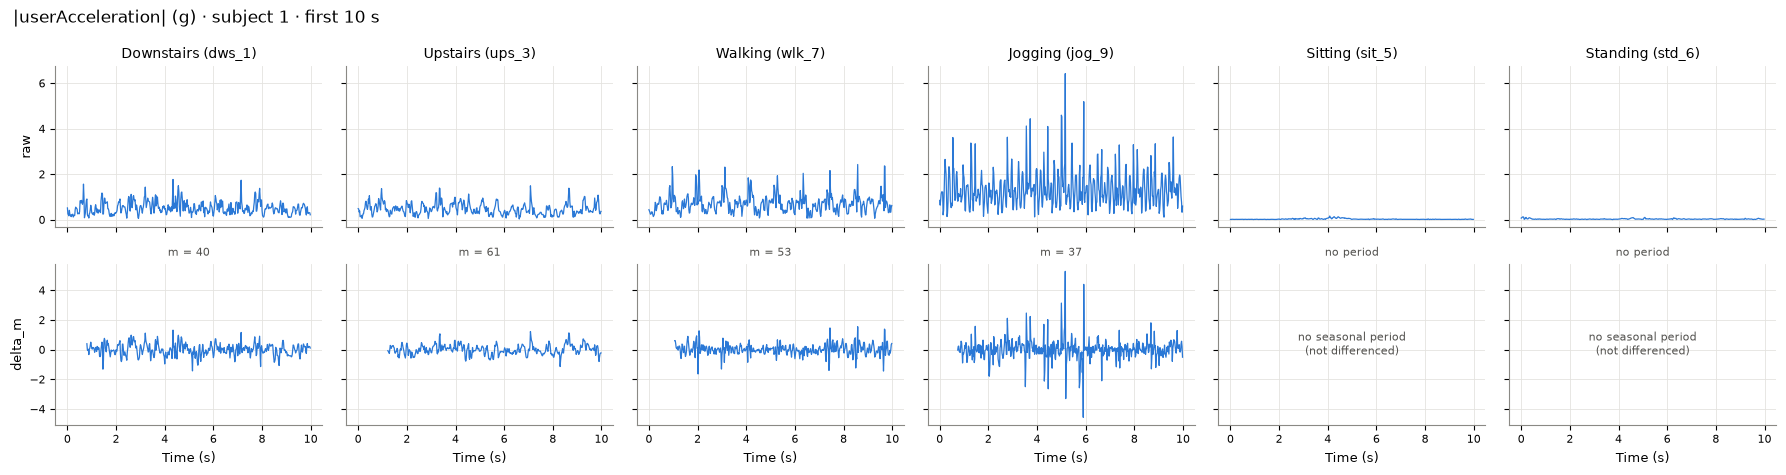

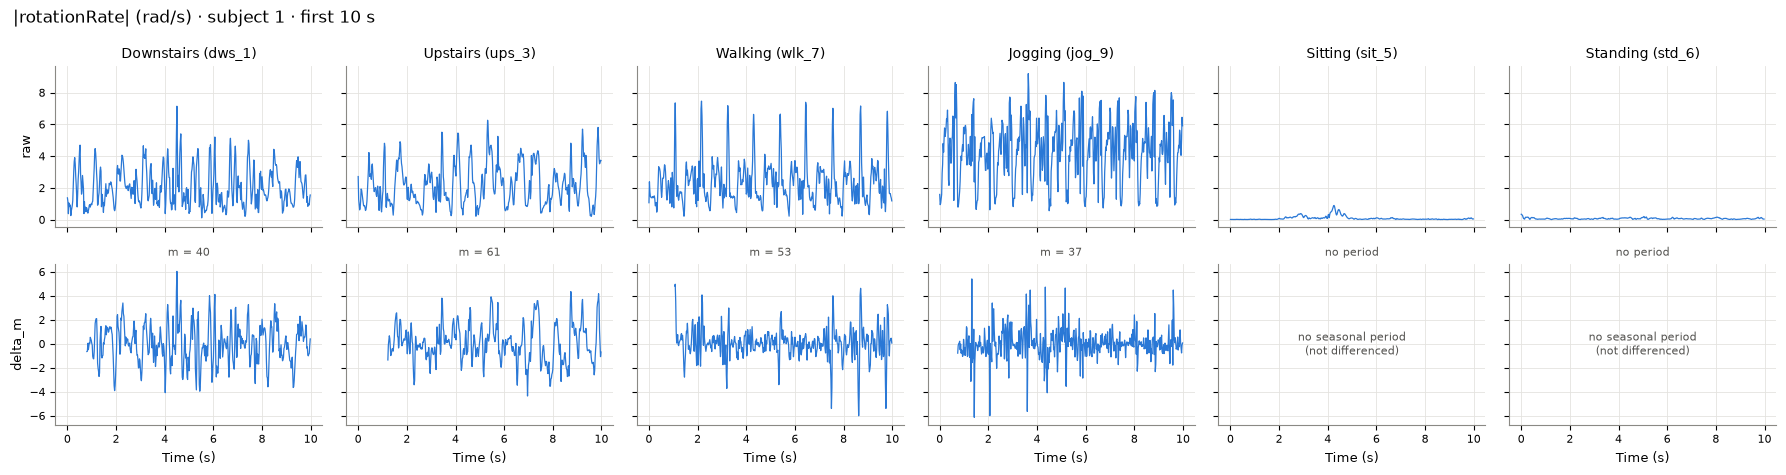

In [ ]:
for name, cols in GROUPS.items():
    fig, axes = plt.subplots(2, len(ACTIVITY_ORDER), figsize=(18, 4.8), sharex=True, sharey="row")
    for j, act in enumerate(ACTIVITY_ORDER):
        trial = TRIALS[act][0]
        for i, data in enumerate([df, df_diff]):
            rec = get_recording(act, trial, SUBJECT, WINDOW_S, data)
            for col, color in zip(cols, COLORS):
                axes[i, j].plot(rec.time_s, rec[col], color=color, linewidth=0.9, label=col.split(".")[-1])
            if rec.empty:
                axes[i, j].text(0.5, 0.5, "no seasonal period\n(not differenced)", ha="center", va="center",
                                transform=axes[i, j].transAxes, fontsize=8, color="#52514e")
        axes[0, j].set_title(f"{ACTIVITY_NAMES[act]} ({act}_{trial})")
        axes[1, j].set_title(m_label(act, trial, SUBJECT), fontsize=8, color="#52514e")
    axes[0, 0].set_ylabel("raw")
    axes[1, 0].set_ylabel("delta_m")
    for ax in axes[-1]:
        ax.set_xlabel("Time (s)")
    if len(cols) > 1:
        axes[0, -1].legend(loc="lower right", bbox_to_anchor=(1, 1.12), ncols=3, frameon=False)
    fig.suptitle(f"{name} · subject {SUBJECT} · first {WINDOW_S} s", x=0.01, ha="left")
    plt.tight_layout()
    plt.show()

### Selected recording before vs after

One figure per sensor group: raw | delta_m. The delta_m series starts `m` samples late because the first season has nothing to subtract.

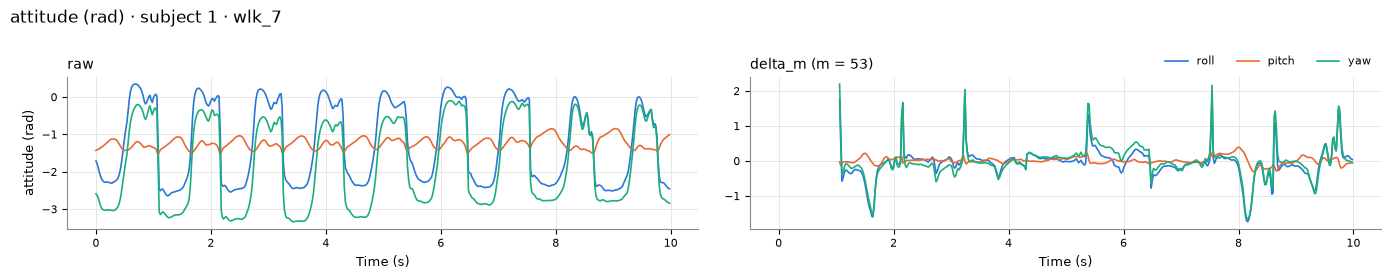

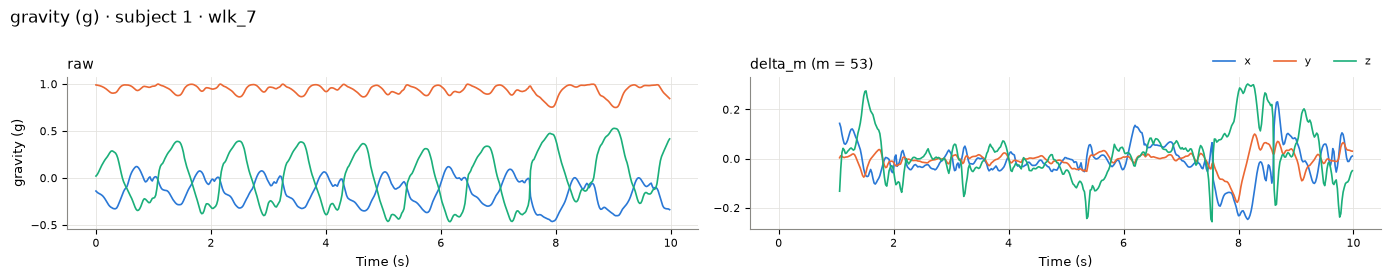

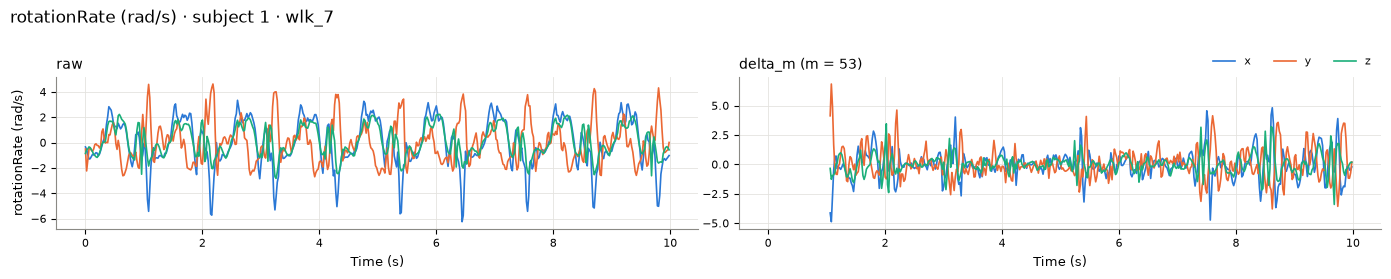

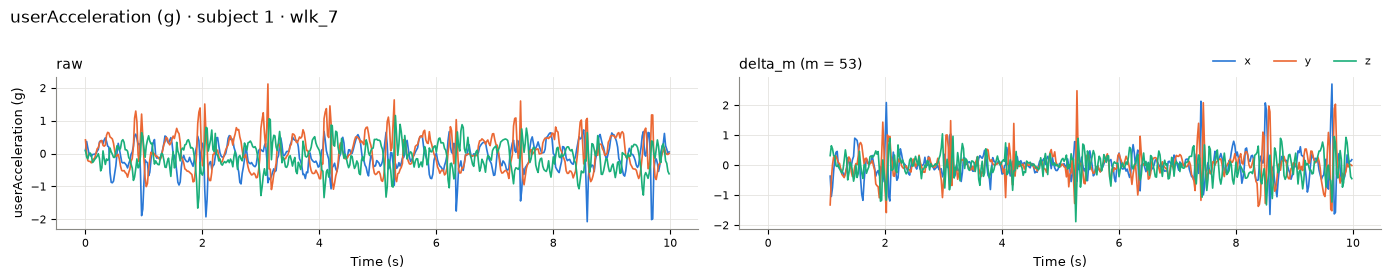

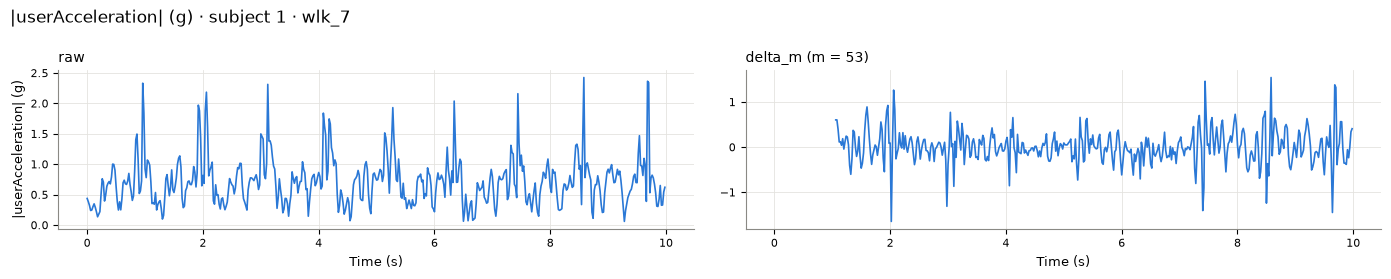

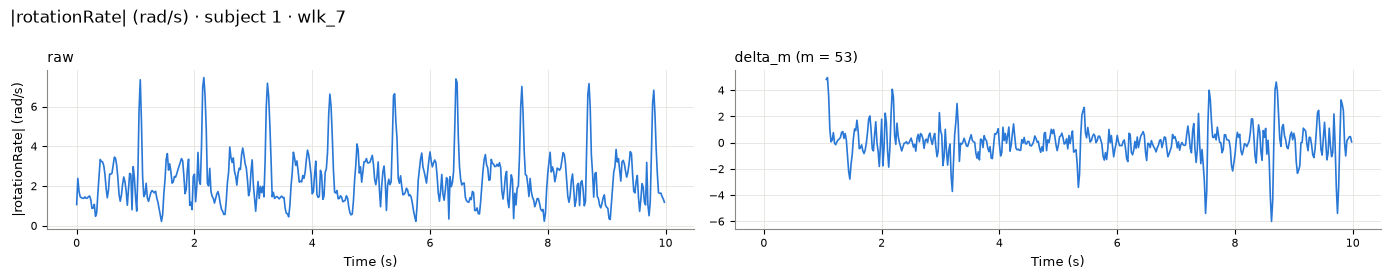

In [ ]:
raw = get_recording(ACTIVITY, TRIAL, SUBJECT, WINDOW_S)
dif = get_recording(ACTIVITY, TRIAL, SUBJECT, WINDOW_S, df_diff)

for name, cols in GROUPS.items():
    fig, axes = plt.subplots(1, 2, figsize=(14, 2.8), sharex=True)
    for ax, data, title in zip(axes, [raw, dif], ["raw", f"delta_m ({m_label(ACTIVITY, TRIAL, SUBJECT)})"]):
        for col, color in zip(cols, COLORS):
            ax.plot(data.time_s, data[col], color=color, label=col.split(".")[-1])
        ax.set_title(title, loc="left")
        ax.set_xlabel("Time (s)")
    axes[0].set_ylabel(name)
    if len(cols) > 1:
        axes[1].legend(loc="lower right", bbox_to_anchor=(1, 1), ncols=3, frameon=False)
    fig.suptitle(f"{name} · subject {SUBJECT} · {ACTIVITY}_{TRIAL}", x=0.01, ha="left")
    plt.tight_layout()
    plt.show()